In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [2]:
# Set the seed for reproducibility
np.random.seed(42)

In [3]:
# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

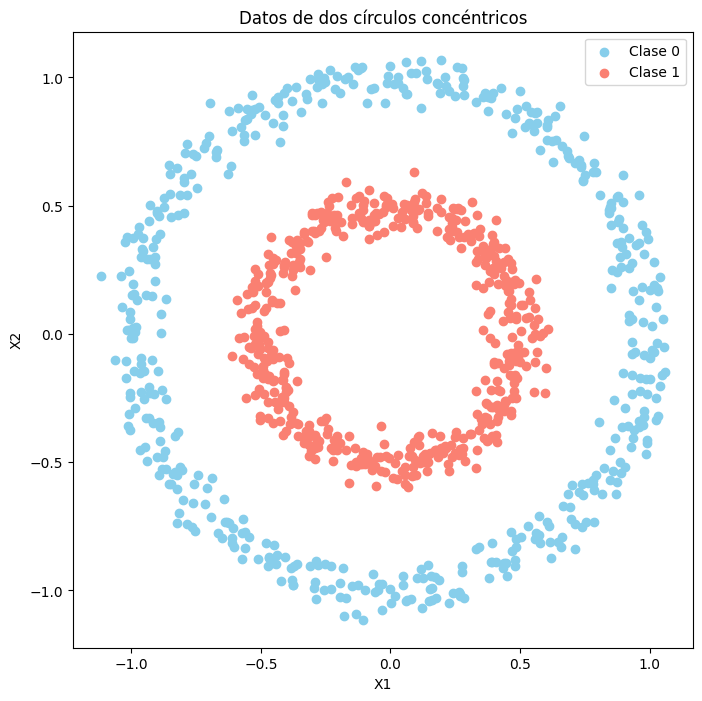

In [4]:
# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# dividir en 85 % entrenamiento / 15 % test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42, stratify=Y
)

print(f"tamaño train: {X_train.shape[0]}, test: {X_test.shape[0]}")

tamaño train: 850, test: 150


In [6]:
#Como el modelo es de clasificacion binomial quiero que uses sigmoid como funcion de activacion, y binary_crossentropy como funcion de perdida. Entrena el modelo durante 100 epocas con un batch size de 32. Ademas quiero que uses 3 capas ocultas, la primera con 16, la segunda con 8 y  la tercera con 4 neuronas. Usa el optimizador Adam con un learning rate 0.3
from tensorflow import keras
from tensorflow.keras import layers
# Crear el modelo secuencial
model = keras.Sequential(
    [
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [9]:
#Crear una variable de EarlyStopping para evitar el sobreentrenamiento
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    min_delta=0.001
)

In [10]:
# Entrenar el modelo
history = model.fit(X_train, Y_train, epochs=1000, batch_size=32, validation_split=0.15, callbacks=[early_stopping])

Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5754 - loss: 0.6614 - val_accuracy: 0.6406 - val_loss: 0.5850
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8184 - loss: 0.5202 - val_accuracy: 0.9766 - val_loss: 0.2981
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9921 - loss: 0.2297 - val_accuracy: 1.0000 - val_loss: 0.0796
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0529 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1

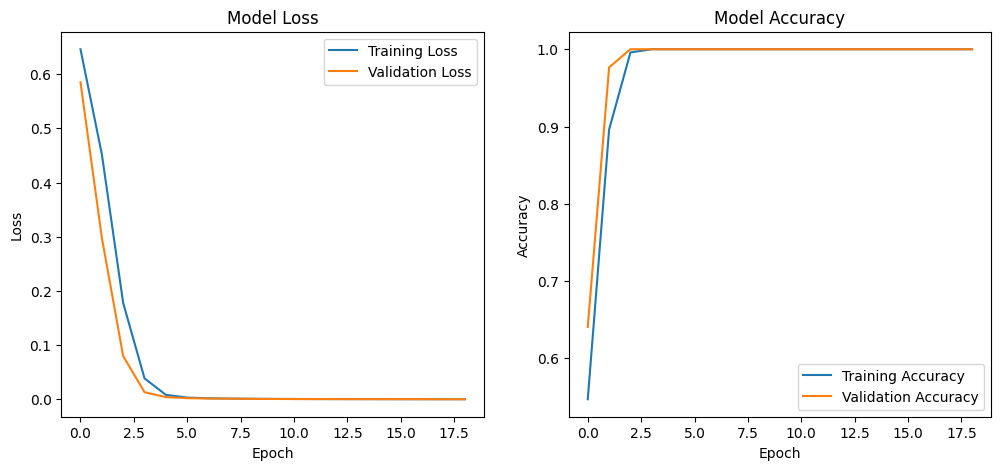

In [11]:
#Haz la grafica de la perdida y la precision del modelo durante el entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 1.0000 - loss: 6.9750e-04
Test Loss: 0.0008, Test Accuracy: 1.0000


In [ ]:
#Conectar con el Drive y guardar el modelo entrenado
from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/MyDrive/modelo_circulos.h5')